## Overall Structure
1. Introduction
2. Data Loading & Understanding
3. Exploratory Data Analysis
4. Data Preprocessing
5. Modeling
6. Model Evaluation
7. Feature Importance
8. Final Model & Results
9. Conclusion

<a name="introduction"></a>
## 1. Introduction: Why Seismic Early-Warning Matters

#### Tsunamis are among the deadliest natural hazards

A large offshore earthquake can displace the sea floor and trigger a **tsunami** — a series of long-wavelength ocean waves capable of reaching coastlines within minutes and causing catastrophic loss of life.

Two examples that put the stakes in perspective:
- **2004 Indian Ocean tsunami:** ~230,000 deaths across 14 countries
- **2011 Tōhoku tsunami (Japan):** ~20,000 deaths

#### Not every earthquake causes a tsunami

Whether an earthquake generates a tsunami depends on several physical factors, not size alone:
- **Magnitude** — larger earthquakes carry more energy to displace water
- **Depth** — shallow earthquakes disturb the sea floor far more effectively than deep ones
- **Location** — the event generally needs to occur offshore or near a coastline
- **Fault motion** — vertical displacement generates tsunamis; horizontal (strike-slip) motion typically does not

This is exactly why a blanket "big earthquake = tsunami" rule isn't reliable, and why a model that learns from historical patterns across these factors can add real value.

#### Why this matters to me personally

This project isn't just an academic exercise. A few months ago, I experienced an earthquake firsthand — thankfully light, and no one was hurt. But in the moment itself, it was genuinely frightening. That experience made the value of early-warning systems concrete to me in a way statistics alone never could: even a few minutes of advance warning can be the difference between people reaching safety and people being caught off guard.

#### Where AI fits in

Operational tsunami warning centres, such as the [Pacific Tsunami Warning Center](https://www.tsunami.gov/), combine rule-based procedures with numerical modelling. Machine learning can support this process by:
- **Rapidly triaging incoming events** to help focus expert attention where it matters most
- **Learning historical patterns** across feature combinations that reliably indicate tsunami risk
- **Providing a probability estimate**, rather than only a binary yes/no signal

#### The task

Given standard earthquake catalog data — magnitude, depth, location, and station-quality metrics — can a model reliably flag the earthquakes most likely to be associated with tsunami risk?

> **Note:** This is an early step in a longer journey, not a deployable system. Operational tsunami warning depends on infrastructure and expertise — deep-ocean sensors, tide gauges, hydrodynamic modelling, expert seismologist review — built over years, not replicated here. What matters at this stage is building the right instincts early: rigorous evaluation, honest interpretation, and a clear sense of where a model's authority ends and human expertise must take over.

#### Beyond the baseline

This project follows the standard machine learning workflow for tabular classification: exploring the data, defining features and a target, training baseline and machine learning models, and evaluating performance under severe class imbalance. It then extends further by:
- Applying **SHAP** to interpret which features actually drive the model's predictions
- Comparing **gradient-boosted models** (XGBoost / LightGBM) against the baseline approach
- Discussing the real-world **limitations and responsible-use considerations** a model like this would face before ever informing an actual warning system

## 2. Data Loading and Understanding


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import folium
from folium.plugins import MarkerCluster, HeatMap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Plotting style
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

SEED = 42
np.random.seed(SEED)

print("All libraries imported successfully")

All libraries imported successfully


---
<a name="data-description"></a>
## Data Description

#### Source: USGS Earthquake Catalog

We use the [USGS Earthquake Catalog](https://earthquake.usgs.gov/earthquakes/search/), accessed via the [FDSN Event Web Service API](https://earthquake.usgs.gov/fdsnws/event/1/). The US Geological Survey maintains the authoritative global earthquake database, updated in near real time.

- **Coverage:** Global, from 1900 to present
- **Contents:** Every located earthquake with magnitude, depth, location, time, and quality-control metadata
- **Access:** Free, no API key, no registration
- **Licence:** Public domain — US Government work
- **What we use:** All M4.5+ earthquakes from 2015 to 2024

#### Key variables

| Column | What it means | Unit |
|---|---|---|
| `time` | When the earthquake happened | UTC timestamp |
| `latitude`, `longitude` | Where the epicentre was | degrees |
| `depth` | How deep beneath the surface | km |
| `mag` | Magnitude (energy released) | Mw scale |
| `nst` | How many seismic stations recorded it | count |
| `gap` | Largest azimuthal gap between stations | degrees |
| `dmin` | Distance to nearest station | degrees |
| `rms` | Location-fit residual | seconds |
| `horizontalError` | Uncertainty in the epicentre location | km |
| `depthError` | Uncertainty in the depth | km |
| `tsunami` | **Target:** did USGS flag this event as tsunami-relevant? | 0 or 1 |


In [53]:
import pandas as pd

START, END, MINMAG = "2015-01-01", "2024-12-31", 4.5
url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?"
    f"format=csv&starttime={START}&endtime={END}&minmagnitude={MINMAG}"
)

try:
    df = pd.read_csv(url)
    print(f"Fetched {len(df):,} earthquakes from the USGS live API")
except Exception as e:
    print(f"Live API unavailable. Using the prototype file.")
    df = pd.read_csv("usgs_prototype.csv")

Live API unavailable. Using the prototype file.


In [54]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,place,type,horizontalError,depthError,magError,magNst,tsunami
0,2015-01-01T00:00:00.000Z,3.6586,134.7037,15.71,4.78,mww,76.0,55.8,2.463,0.24,ci,us700000000,off the coast of Japan,earthquake,2.05,2.79,0.086,45,0
1,2015-01-01T10:57:26.530Z,-9.8327,-94.2316,12.49,6.31,mb,92.0,96.0,1.710,NaN,us,us700000001,near the coast of Chile,earthquake,5.03,3.25,0.143,55,0
2,2015-01-01T21:54:53.061Z,32.7159,26.5746,15.22,5.29,mww,NaN,135.5,0.390,0.80,ci,us700000002,Iran,earthquake,2.62,8.52,0.072,51,0
3,2015-01-02T08:52:19.592Z,40.0083,-6.7204,11.42,5.05,mb,75.0,17.1,0.055,0.41,us,us700000003,Greece,earthquake,1.07,1.13,0.099,45,0
4,2015-01-02T19:49:46.123Z,46.2714,60.7881,333.49,4.60,md,87.0,133.0,0.482,0.76,us,us700000004,central Italy,earthquake,6.63,2.75,0.199,52,0


#### How big is the dataset?

In [55]:
print(f"Number of rows (earthquakes): {df.shape[0]:,}")
print(f"Number of columns (variables): {df.shape[1]}")
print(f"\nDate range: {df['time'].min()[:10]} → {df['time'].max()[:10]}")
print(f"That's about {(pd.to_datetime(df['time'].max()) - pd.to_datetime(df['time'].min())).days / 365:.1f} years of data")

Number of rows (earthquakes): 8,000
Number of columns (variables): 19

Date range: 2015-01-01 → 2024-12-31
That's about 10.0 years of data


#### What are the columns?


In [56]:
print("All columns in the dataset:")
print(df.dtypes)

All columns in the dataset:
time                object
latitude           float64
longitude          float64
depth              float64
mag                float64
magType             object
nst                float64
gap                float64
dmin               float64
rms                float64
net                 object
id                  object
place               object
type                object
horizontalError    float64
depthError         float64
magError           float64
magNst               int64
tsunami              int64
dtype: object


#### Are there missing values?


In [57]:
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0].sort_values(ascending=False)

if len(missing_nonzero) == 0:
    print("✅ No missing values anywhere in the dataset")
else:
    print("Columns with missing values:")
    print(missing_nonzero.to_string())
    print(f"\nTotal missing values: {missing_nonzero.sum():,} ({missing_nonzero.sum()/df.size*100:.2f}% of all cells)")

Columns with missing values:
nst                168
magError           162
rms                160
depthError         160
horizontalError    149
gap                148
dmin               139

Total missing values: 1,086 (0.71% of all cells)


#### Summary statistics for the numeric columns

In [58]:
main_cols = ['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'tsunami']
df[main_cols].describe().round(2)

,latitude,longitude,depth,mag,nst,gap,tsunami
count,8000.00,8000.00,8000.00,8000.00,7832.00,7852.00,8000.00
mean,15.11,28.46,84.35,5.09,80.18,80.57,0.03
std,26.66,102.87,130.93,0.59,7.87,40.88,0.16
min,-60.00,-179.92,0.00,4.50,56.00,10.00,0.00
25%,-4.58,-70.17,6.56,4.67,75.00,45.10,0.00
50%,23.42,40.97,18.55,4.91,80.00,81.10,0.00
75%,35.67,123.50,125.98,5.32,85.00,116.00,0.00
max,80.00,179.98,700.00,9.40,127.00,299.70,1.00


**What to notice:**

- **`mag`** — minimum is 4.5 (that's the filter we applied). Maximum is around 8-9 (the largest earthquakes in the past decade).
- **`depth`** — ranges from about 0 km (surface) to several hundred km deep. Most are shallow.
- **`nst`** — number of stations that recorded each event, ranges from a handful to over a hundred.
- **`tsunami`** — mean is around 0.03, meaning about 3% of events triggered a tsunami flag. We'll look at this more closely next.

#### The target variable — how balanced is it?

In [59]:
tsunami_counts = df['tsunami'].value_counts()
total = len(df)

print("Tsunami flag distribution:")
print(f"  0 (no tsunami):  {tsunami_counts.get(0, 0):>6,}  ({tsunami_counts.get(0, 0)/total*100:5.1f}%)")
print(f"  1 (tsunami):     {tsunami_counts.get(1, 0):>6,}  ({tsunami_counts.get(1, 0)/total*100:5.1f}%)")
print()
print("→ Only a small fraction of earthquakes trigger tsunamis.")
print("  This is called an IMBALANCED classification problem.")


Tsunami flag distribution:
  0 (no tsunami):   7,791  ( 97.4%)
  1 (tsunami):        209  (  2.6%)

→ Only a small fraction of earthquakes trigger tsunamis.
  This is called an IMBALANCED classification problem.


#### Precision, Recall, and Why They Matter Here

With tsunami-triggering earthquakes making up only ~3% of the data, accuracy alone is a poor metric — a model that always predicts "no tsunami" would be 97% accurate while being completely useless.

**Precision** — of the events flagged as tsunami-relevant, how many actually were?
`Precision = TP / (TP + FP)`

**Recall** — of the actual tsunami-relevant events, how many did the model catch?
`Recall = TP / (TP + FN)`

These trade off against each other: a more sensitive model catches more real events (higher recall) at the cost of more false alarms (lower precision). Since missing a real tsunami is far more costly than a false alarm, **recall is prioritized over precision** in this project.

**F1 score** combines both into one number, staying high only when precision and recall are both reasonably strong.

**AUC-ROC** measures something different: ignoring any specific decision threshold, how well does the model rank earthquakes from most to least likely to trigger a tsunami — independent of where the 0–1 cutoff is set.

#

#### Visualize the Data

Numbers are useful but plots reveal patterns you would otherwise miss.

#### An interactive world map of earthquakes and tsunamis

We use the **Folium** library to create a fully interactive world map. You can zoom, pan, and click each earthquake to see its details.

- **Blue circles** = earthquakes that did NOT trigger a tsunami
- **Red circles** = earthquakes that were flagged as tsunami-triggering

Small blue dots are clustered together so the map stays fast even with thousands of events. Red tsunami-triggering events are shown individually so you can click each one.

In [60]:
world_map = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB positron",
    world_copy_jump=True,
)


non_tsunami_cluster = MarkerCluster(name="Non-tsunami earthquakes",
                                     control=True).add_to(world_map)


np.random.seed(SEED)
non_tsunami = df[df['tsunami'] == 0]
if len(non_tsunami) > 2000:
    non_tsunami = non_tsunami.sample(2000, random_state=SEED)

for _, row in non_tsunami.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='steelblue',
        fill=True, fill_opacity=0.5,
        popup=f"M{row['mag']:.1f} at depth {row['depth']:.0f} km",
    ).add_to(non_tsunami_cluster)

# ── Tsunami-triggering earthquakes: show individually, all in red ────────────
tsunami_layer = folium.FeatureGroup(name="🌊 Tsunami-triggering earthquakes",
                                     show=True).add_to(world_map)

for _, row in df[df['tsunami'] == 1].iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color='darkred',
        fill=True, fill_color='crimson', fill_opacity=0.85,
        weight=1.5,
        popup=folium.Popup(
            f"<b>Tsunami event</b><br>"
            f"Magnitude: {row['mag']:.1f}<br>"
            f"Depth: {row['depth']:.0f} km<br>"
            f"Location: {row['place']}<br>"
            f"Date: {row['time'][:10]}",
            max_width=250,
        ),
    ).add_to(tsunami_layer)

folium.LayerControl(collapsed=False).add_to(world_map)

world_map

#

#### Distribution of magnitude and depth

Two histograms showing how magnitudes and depths are distributed. Understanding these distributions will help us pick good features later.

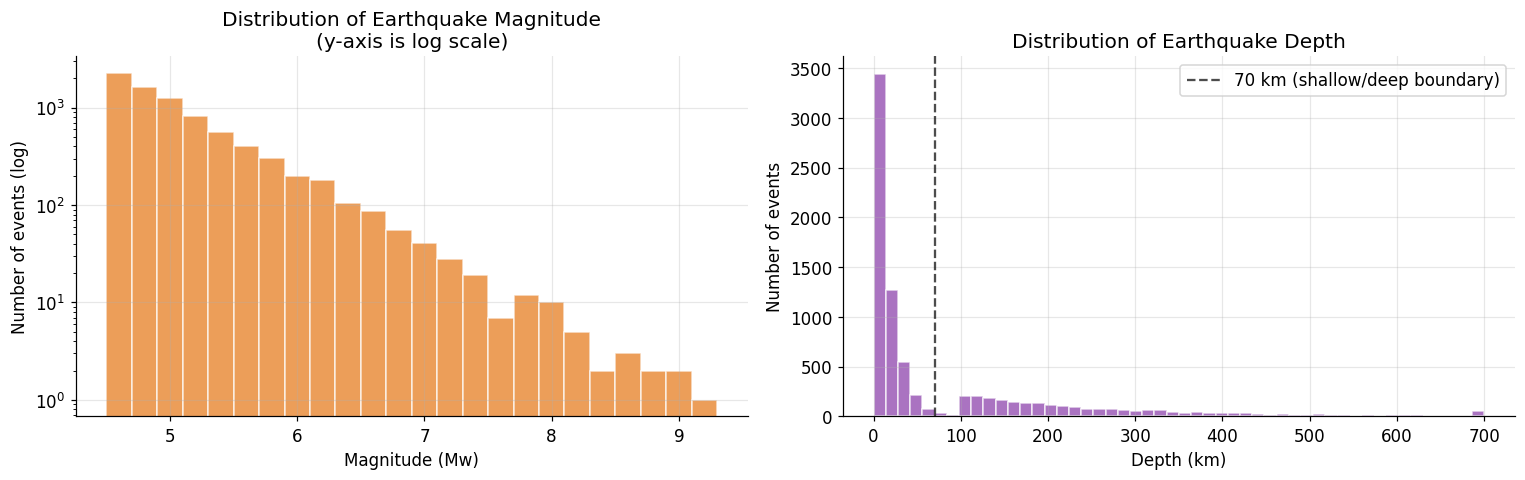

Observations:
  • Magnitude: median = 4.9, max = 9.4
  • Depth:     median = 18.5 km, max = 700 km
  • Fraction of shallow (<70 km) earthquakes: 69.4%


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(df['mag'], bins=np.arange(4.5, 9.5, 0.2),
             color='#e67e22', alpha=0.75, edgecolor='white')
axes[0].set_yscale('log')  # log scale because small earthquakes are MUCH more common
axes[0].set_title("Distribution of Earthquake Magnitude\n(y-axis is log scale)")
axes[0].set_xlabel("Magnitude (Mw)")
axes[0].set_ylabel("Number of events (log)")

axes[1].hist(df['depth'].dropna(), bins=50,
             color='#8e44ad', alpha=0.75, edgecolor='white')
axes[1].axvline(70, color='black', ls='--', alpha=0.7,
                label='70 km (shallow/deep boundary)')
axes[1].set_title("Distribution of Earthquake Depth")
axes[1].set_xlabel("Depth (km)")
axes[1].set_ylabel("Number of events")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Observations:")
print(f"  • Magnitude: median = {df['mag'].median():.1f}, max = {df['mag'].max():.1f}")
print(f"  • Depth:     median = {df['depth'].median():.1f} km, max = {df['depth'].max():.0f} km")
print(f"  • Fraction of shallow (<70 km) earthquakes: {(df['depth']<70).mean()*100:.1f}%")

#

#### Tsunami rate by magnitude — the key predictor

This chart shows what fraction of earthquakes in each magnitude range triggered a tsunami. This is arguably the most important plot in the whole notebook — it tells us which feature will matter most.

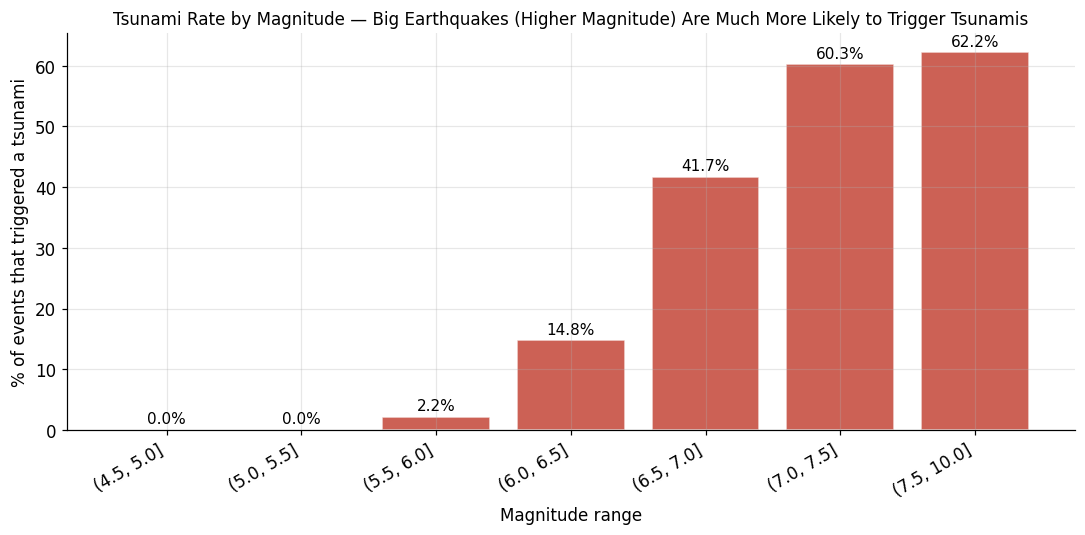

Takeaway:
  • Below M5.5: tsunamis almost never happen (<1%)
  • Between M6.5-7.0: about 1 in 4 events trigger a tsunami
  • Above M7.0: majority trigger tsunamis
  → Magnitude will clearly be a strong predictor for our model


In [62]:
df_temp = df.copy()
df_temp['mag_bin'] = pd.cut(df_temp['mag'], bins=[4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 10])
tsunami_rate = df_temp.groupby('mag_bin', observed=True)['tsunami'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(tsunami_rate)), tsunami_rate.values,
              color='#c0392b', alpha=0.8, edgecolor='white')

for bar, val in zip(bars, tsunami_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)

ax.set_xticks(range(len(tsunami_rate)))
ax.set_xticklabels([str(x) for x in tsunami_rate.index], rotation=30, ha='right')
ax.set_title("Tsunami Rate by Magnitude — Big Earthquakes (Higher Magnitude) Are Much More Likely to Trigger Tsunamis",
             fontsize=11)
ax.set_xlabel("Magnitude range")
ax.set_ylabel("% of events that triggered a tsunami")
plt.tight_layout()
plt.show()

print("Takeaway:")
print("  • Below M5.5: tsunamis almost never happen (<1%)")
print("  • Between M6.5-7.0: about 1 in 4 events trigger a tsunami")
print("  • Above M7.0: majority trigger tsunamis")
print("  → Magnitude will clearly be a strong predictor for our model")

#### How does depth affect the tsunami rate?

Let's do the same analysis for depth. Shallow earthquakes should be more likely to generate tsunamis.

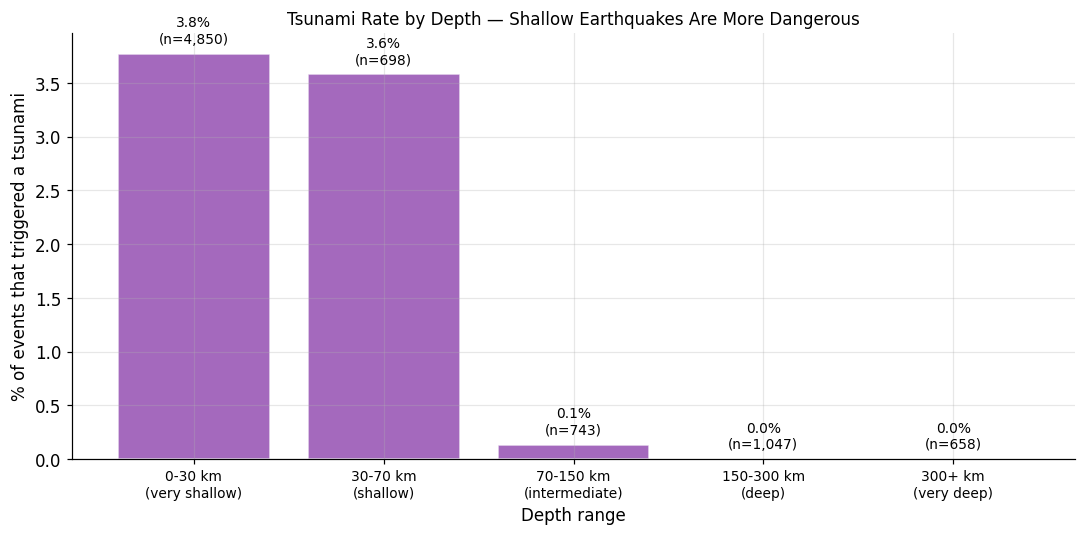

Takeaway: Very shallow earthquakes (<70 km) are MUCH more likely to trigger tsunamis
than deep ones. This matches the physics — deep earthquakes don't move the sea floor.


In [63]:
df_temp = df.copy()
df_temp['depth_bin'] = pd.cut(df_temp['depth'], bins=[0, 30, 70, 150, 300, 700])
depth_rate  = df_temp.groupby('depth_bin', observed=True)['tsunami'].mean() * 100
depth_count = df_temp.groupby('depth_bin', observed=True).size()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(depth_rate)), depth_rate.values,
              color='#8e44ad', alpha=0.8, edgecolor='white')

for bar, val, cnt in zip(bars, depth_rate.values, depth_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%\n(n={cnt:,})', ha='center', fontsize=9)

ax.set_xticks(range(len(depth_rate)))
ax.set_xticklabels(['0-30 km\n(very shallow)', '30-70 km\n(shallow)',
                    '70-150 km\n(intermediate)', '150-300 km\n(deep)',
                    '300+ km\n(very deep)'], fontsize=9)
ax.set_title("Tsunami Rate by Depth — Shallow Earthquakes Are More Dangerous", fontsize=11)
ax.set_xlabel("Depth range")
ax.set_ylabel("% of events that triggered a tsunami")
plt.tight_layout()
plt.show()

print("Takeaway: Very shallow earthquakes (<70 km) are MUCH more likely to trigger tsunamis")
print("than deep ones. This matches the physics — deep earthquakes don't move the sea floor.")

#

 #### Handle missing values

In [64]:
df_clean = df.copy()

numeric_impute = ['nst', 'gap', 'dmin', 'rms',
                  'horizontalError', 'depthError', 'magError', 'magNst']
for col in numeric_impute:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

remaining = df_clean[numeric_impute].isnull().sum().sum()
print(f"Missing values after imputation: {remaining}")

Missing values after imputation: 0


#### Note on cyclic encoding for latitude and longitude

Longitude wraps around at ±180° — for example, 179° and -179° are almost the same location on Earth, just approached from opposite directions. Fed to a model as raw numbers, however, they'd appear nearly 360 units apart, which would corrupt any location-based pattern the model tries to learn.

Sine and cosine convert each longitude into a position on a circle, correctly preserving true geographic closeness across that wrap-around boundary — this matters here since much of our seismic activity clusters along the **Pacific Ring of Fire**, a region that spans this exact longitude seam.

In [65]:
# Three points on Earth:
locations = {
    "Fiji (east side)":    179.0,
    "Fiji (west side)":   -179.0,
    "London":                0.0,
}

print("Raw longitude 'distances' (subtracting the numbers):")
print(f"  Fiji-east to Fiji-west: {abs(179.0 - (-179.0)):.1f} units")
print(f"  London    to Fiji-east: {abs(0.0 - 179.0):.1f} units")
print()
print("→ Raw math says Fiji-east and Fiji-west are 358 units apart —")
print("  further than London is from Fiji. That's obviously wrong.")
print()

def cyclic_distance(lon_a, lon_b):
    a_sin, a_cos = np.sin(np.radians(lon_a)), np.cos(np.radians(lon_a))
    b_sin, b_cos = np.sin(np.radians(lon_b)), np.cos(np.radians(lon_b))
    return np.sqrt((a_sin - b_sin)**2 + (a_cos - b_cos)**2)

print("With cyclic (sin, cos) encoding:")
print(f"  Fiji-east to Fiji-west: {cyclic_distance(179.0, -179.0):.4f} — small (correct!)")
print(f"  London    to Fiji-east: {cyclic_distance(0.0, 179.0):.4f} — large (correct!)")
print()
print("→ The two Fiji points are now close together, and London is far away —")
print("  which matches physical reality on the sphere.")

Raw longitude 'distances' (subtracting the numbers):
  Fiji-east to Fiji-west: 358.0 units
  London    to Fiji-east: 179.0 units

→ Raw math says Fiji-east and Fiji-west are 358 units apart —
  further than London is from Fiji. That's obviously wrong.

With cyclic (sin, cos) encoding:
  Fiji-east to Fiji-west: 0.0349 — small (correct!)
  London    to Fiji-east: 1.9999 — large (correct!)

→ The two Fiji points are now close together, and London is far away —
  which matches physical reality on the sphere.


#### Seeing the Wrap-Around Fix Visually

The plot below shows longitude values mapped onto a circle instead of a straight line. Watch how the points flow smoothly from one side to the other — no sudden jump between -180° and +180°, unlike the raw values.

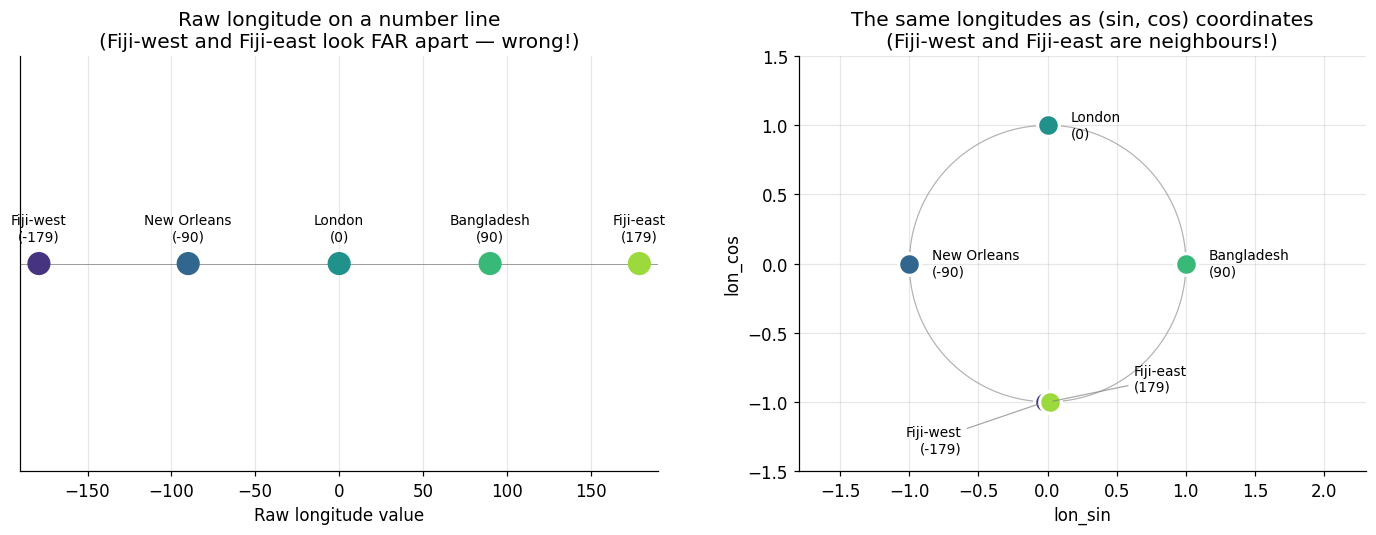

→ On the LEFT (raw longitude), Fiji-west and Fiji-east are at opposite ends.
→ On the RIGHT (cyclic encoding), they sit next to each other on the circle.
  The second picture is what a machine learning model 'sees' when we use sin/cos.


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: longitude on a number line (the WRONG representation) ────────
lons_sample = np.array([-179, -90, 0, 90, 179])
labels = ["Fiji-west\n(-179)", "New Orleans\n(-90)", "London\n(0)",
          "Bangladesh\n(90)", "Fiji-east\n(179)"]
colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(lons_sample)))

axes[0].scatter(lons_sample, np.zeros_like(lons_sample), s=200, c=colours, zorder=3)
for lon, lab, c in zip(lons_sample, labels, colours):
    axes[0].annotate(lab, (lon, 0), xytext=(0, 15), textcoords='offset points',
                     ha='center', fontsize=9)
axes[0].axhline(0, color='grey', lw=0.5)
axes[0].set_xlim(-190, 190)
axes[0].set_ylim(-1, 1)
axes[0].set_xlabel("Raw longitude value")
axes[0].set_title("Raw longitude on a number line\n(Fiji-west and Fiji-east look FAR apart — wrong!)")
axes[0].set_yticks([])

# ── Right panel: same points on the unit circle (the CORRECT representation) ─
lons_dense = np.linspace(-180, 180, 361)
axes[1].plot(np.sin(np.radians(lons_dense)), np.cos(np.radians(lons_dense)),
             'grey', lw=0.8, alpha=0.6)

label_offsets = {
    "Fiji-west\n(-179)": ((-55, -25), 'right'),
    "Fiji-east\n(179)":  ((55, 15),  'left'),
}
default_offset, default_ha = (15, 0), 'left'

for lon, lab, c in zip(lons_sample, labels, colours):
    x = np.sin(np.radians(lon))
    y = np.cos(np.radians(lon))

    offset, ha = label_offsets.get(lab, (default_offset, default_ha))

    axes[1].scatter(x, y, s=200, c=[c], zorder=3, edgecolor='white', lw=2)
    axes[1].annotate(
        lab, (x, y),
        xytext=offset, textcoords='offset points',
        ha=ha, va='center', fontsize=9,
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.8, alpha=0.7)
        if lab in label_offsets else None,
    )

axes[1].set_xlim(-1.8, 2.3)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect('equal')
axes[1].set_xlabel("lon_sin")
axes[1].set_ylabel("lon_cos")
axes[1].set_title("The same longitudes as (sin, cos) coordinates\n(Fiji-west and Fiji-east are neighbours!)")

plt.tight_layout(); plt.show()

print("→ On the LEFT (raw longitude), Fiji-west and Fiji-east are at opposite ends.")
print("→ On the RIGHT (cyclic encoding), they sit next to each other on the circle.")
print("  The second picture is what a machine learning model 'sees' when we use sin/cos.")

#### Applying the Encoding, and Flagging Shallow Events

With the reasoning in place, latitude and longitude are converted into their sine/cosine pairs directly on the dataset.

A second engineered feature is added here too: a **`shallow`** flag, marking earthquakes shallower than 70 km. Shallow events disturb the sea floor far more effectively and are disproportionately more likely to generate a tsunami — making this distinction explicit as its own feature, rather than leaving the model to infer it purely from raw depth values.

In [67]:
# ── Cyclic encoding for latitude and longitude ──────────────────────────────
df_clean['lat_sin'] = np.sin(np.radians(df_clean['latitude']))
df_clean['lat_cos'] = np.cos(np.radians(df_clean['latitude']))
df_clean['lon_sin'] = np.sin(np.radians(df_clean['longitude']))
df_clean['lon_cos'] = np.cos(np.radians(df_clean['longitude']))

# ── Also create a boolean flag for shallow earthquakes ──────────────────────
# Shallow earthquakes are much more likely to generate tsunamis (we saw this
# in Section 4.10), so making this explicit helps the model
df_clean['shallow'] = (df_clean['depth'] < 70).astype(int)

# Look at the first few rows of the new features
df_clean[['latitude', 'lat_sin', 'lat_cos', 'longitude', 'lon_sin', 'lon_cos', 'shallow']].head()

,latitude,lat_sin,lat_cos,longitude,lon_sin,lon_cos,shallow
0,3.6586,0.063811,0.997962,134.7037,0.710754,-0.703441,1
1,-9.8327,-0.170772,0.985311,-94.2316,-0.997274,-0.073788,1
2,32.7159,0.540474,0.841361,26.5746,0.447363,0.894353,1
3,40.0083,0.642899,0.765951,-6.7204,-0.117024,0.993129,1
4,46.2714,0.722622,0.691243,60.7881,0.872821,0.488041,0


#### Choose our features and target

Now we assemble the final list of features (predicting variables) that will feed the model.

In [68]:
FEATURES = [
    'mag',              # magnitude — should be the strongest predictor
    'depth',            # depth in km
    'shallow',          # boolean flag for shallow earthquake
    'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos',  # location (cyclic-encoded)
    'nst',              # number of stations that recorded it
    'gap',              # the largest angle between two adjacent seismic stations measuring an earthquake, relative to the epicenter
    'horizontalError',  # location uncertainty
    'depthError',       # depth uncertainty
]
TARGET = 'tsunami'

print(f"Features ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  • {f}")
print(f"\nTarget: {TARGET}")

Features (11):
  • mag
  • depth
  • shallow
  • lat_sin
  • lat_cos
  • lon_sin
  • lon_cos
  • nst
  • gap
  • horizontalError
  • depthError

Target: tsunami


#### Train / Validation / Test Split

The data is split into three parts — training (~ 60%), validation (~ 20%), and test (~ 20%) — since evaluating a model on data it was trained on gives an artificially optimistic result.

Because tsunami-triggering earthquakes are rare (~3% of events), a random split risks putting most tsunami cases into just one split by chance, making the evaluation unstable. **Stratified splitting** (`stratify=y`) avoids this by keeping the tsunami rate consistent across all three splits.

In [69]:
X = df_clean[FEATURES]
y = df_clean[TARGET]

# ── First split: separate out the test set (20%) ────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20% goes to test
    random_state=SEED,    # for reproducibility
    stratify=y            # preserve the class balance
)

# ── Second split: split remaining 80% into 75%/25% → train/val ──────────────
# 75% of 80% = 60% of the original data becomes training
# 25% of 80% = 20% of the original data becomes validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp
)

print(f"{'Split':12s} {'Rows':>6s} {'Tsunamis':>10s} {'Rate':>8s}")
print("-" * 42)
for name, X_, y_ in [("Train", X_train, y_train),
                     ("Validation", X_val, y_val),
                     ("Test", X_test, y_test)]:
    print(f"{name:12s} {len(X_):6d} {int(y_.sum()):10d} {y_.mean()*100:7.2f}%")

print("\n→ Tsunami rate is nearly identical across all three splits — stratification worked.")
print("\n→ Now, we will keep our Test set separate, only to be used when evaluating our model on unseen data.")


Split          Rows   Tsunamis     Rate
------------------------------------------
Train          4800        125    2.60%
Validation     1600         42    2.62%
Test           1600         42    2.62%

→ Tsunami rate is nearly identical across all three splits — stratification worked.

→ Now, we will keep our Test set separate, only to be used when evaluating our model on unseen data.


#### Two Naive Baselines

Before training any real model, it's worth checking how well two simple, non-learning approaches perform — if a more sophisticated model can't beat them, it isn't actually adding value.

1. **Always predict "no tsunami"** — reaches ~97% accuracy purely by exploiting the class imbalance. Included specifically to show why accuracy alone is a misleading metric here.
2. **A seismology-based rule:** flag events with **magnitude ≥ 7.0 AND depth < 70 km**, reflecting the known physical pattern that large, shallow earthquakes are the dangerous ones. If a trained model can't beat this rule, the rule alone is the better choice.

In [70]:
# ── Baseline 1: always predict 0 (no tsunami) ────────────────────────────────
y_baseline_zero = np.zeros(len(y_val), dtype=int)

# ── Baseline 2: simple magnitude-and-depth rule ─────────────────────────────
y_baseline_rule = ((X_val['mag'] >= 7.0) & (X_val['shallow'] == 1)).astype(int).values

# ── Helper function to print all four metrics for a set of predictions. Instead of re-writing and duplicating code, we will call this helper function everytime we need to evaluate metrics──────
def print_metrics(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"{name:42s}  acc={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}  F1={f1:.3f}")

print("BASELINE PERFORMANCE ON VALIDATION SET")
print("=" * 95)
print_metrics("Always predict 'no tsunami'",       y_val, y_baseline_zero)
print_metrics("Rule: M >= 7.0 AND depth < 70 km", y_val, y_baseline_rule)

print()
print("→ Always-predict-zero has HIGH accuracy (~97%) but ZERO recall — useless.")
print("→ The simple rule gets some real recall. THIS is the honest bar we must beat.")


BASELINE PERFORMANCE ON VALIDATION SET
Always predict 'no tsunami'                 acc=0.974  precision=0.000  recall=0.000  F1=0.000
Rule: M >= 7.0 AND depth < 70 km            acc=0.981  precision=0.929  recall=0.310  F1=0.464

→ Always-predict-zero has HIGH accuracy (~97%) but ZERO recall — useless.
→ The simple rule gets some real recall. THIS is the honest bar we must beat.


#### Logistic Regression as the First Learned Model

Logistic Regression is the simplest classifier that actually learns from data — it takes a weighted combination of features and maps the result to a probability between 0 and 1. Despite its simplicity, it's often surprisingly hard to beat on tabular data.

**Scaling:** since features here span very different ranges (some between -1 and 1, others up to 40+), they're standardized — each feature rescaled to mean 0 and standard deviation 1 — since Logistic Regression performs best when all features are on comparable scales.

The scaler is fit **only on the training data**, then applied to validation and test using that same fit. Fitting it on the full dataset would leak information from the test set into training.

In [71]:
# ── Scale the features ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on training
X_val_scaled   = scaler.transform(X_val)         # transform only on val
X_test_scaled  = scaler.transform(X_test)        # transform only on test

# ── Train the model ──────────────────────────────────────────────────────────
# class_weight='balanced' tells the model to care extra about the rare class.
# Without this, it might just learn to always predict "no tsunami" (like Baseline 1).
model = LogisticRegression(
    class_weight='balanced',
    max_iter=500,
    random_state=SEED,
)
model.fit(X_train_scaled, y_train)

print("✅ Model trained")
print(f"   Features used: {model.n_features_in_}")

✅ Model trained
   Features used: 11


#### Evaluating the Model

Accuracy, precision, recall, F1, and AUC-ROC are all computed for Logistic Regression on the validation set. As established earlier, **recall** is the metric that matters most here — a missed real tsunami costs lives, while a false alarm is only costly.

In [72]:
# ── Predict on the validation set ────────────────────────────────────────────
y_pred  = model.predict(X_val_scaled)              # 0 or 1 predictions
y_proba = model.predict_proba(X_val_scaled)[:, 1]  # probability of tsunami

print("MODEL PERFORMANCE ON VALIDATION SET")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_val, y_pred):.3f}")
print(f"Precision: {precision_score(y_val, y_pred):.3f}")
print(f"Recall:    {recall_score(y_val, y_pred):.3f}")
print(f"F1 score:  {f1_score(y_val, y_pred):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_proba):.3f}")

print("\nDetailed classification report:")
print(classification_report(y_val, y_pred,
      target_names=["No tsunami", "Tsunami"], digits=3))

MODEL PERFORMANCE ON VALIDATION SET
Accuracy:  0.934
Precision: 0.283
Recall:    0.976
F1 score:  0.439
AUC-ROC:   0.984

Detailed classification report:
              precision    recall  f1-score   support

  No tsunami      0.999     0.933     0.965      1558
     Tsunami      0.283     0.976     0.439        42

    accuracy                          0.934      1600
   macro avg      0.641     0.955     0.702      1600
weighted avg      0.981     0.934     0.951      1600



#### Confusion matrix

A confusion matrix shows the four possible outcomes:

- **True Negatives** (top-left): correctly predicted no tsunami
- **True Positives** (bottom-right): correctly predicted tsunami
- **False Negatives** (bottom-left): missed real tsunami (the dangerous error)
- **False Positives** (top-right): false alarm

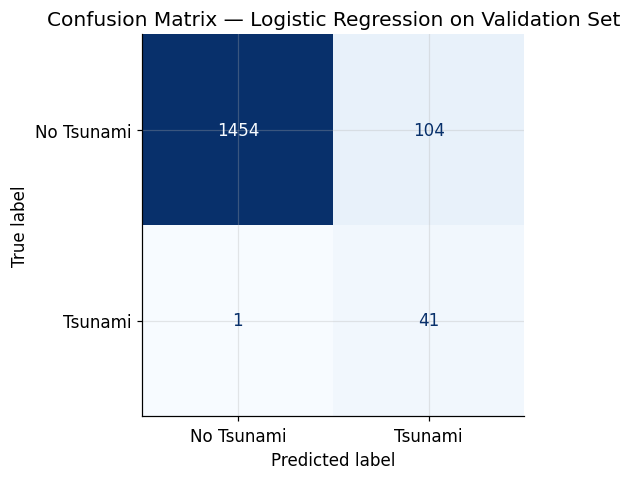

True Negatives  (correctly said no tsunami):  1454
False Positives (false alarms):                104
False Negatives (MISSED tsunamis — bad):         1
True Positives  (correctly caught tsunami):     41


In [73]:
cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(6, 4.5))
disp = ConfusionMatrixDisplay(cm, display_labels=["No Tsunami", "Tsunami"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Logistic Regression on Validation Set")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly said no tsunami):  {tn:>4d}")
print(f"False Positives (false alarms):               {fp:>4d}")
print(f"False Negatives (MISSED tsunamis — bad):      {fn:>4d}")
print(f"True Positives  (correctly caught tsunami):   {tp:>4d}")

#

#### Checking for Overfitting

A model overfits when it learns the training data too precisely — including its noise and one-off quirks — performing well on data it has seen but poorly on new data.

Rather than introducing a separate model just to demonstrate this, the check is done directly on Random Forest by varying max_depth and comparing training F1 against validation F1 at each depth. A small, stable gap between the two suggests the model is generalizing well; a gap that widens as depth increases signals overfitting.

Random Forest is expected to be more resistant to this than a single decision tree, since it averages many trees together — this comparison also tests whether that expected robustness actually holds here.

In [74]:
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]  # None means unlimited depth
train_f1 = []
val_f1   = []

for depth in depths:
    forest = RandomForestClassifier(
        max_depth=depth,
        n_estimators=100,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
    )
    forest.fit(X_train, y_train)
    train_f1.append(f1_score(y_train, forest.predict(X_train)))
    val_f1.append  (f1_score(y_val,   forest.predict(X_val)))

print(f"{'Depth':>7s}   {'Train F1':>9s}   {'Val F1':>7s}   {'Gap':>6s}")
print("-" * 42)
for d, tf, vf in zip(depths, train_f1, val_f1):
    d_str = "None" if d is None else str(d)
    gap = tf - vf
    marker = "  ← overfitting" if gap > 0.3 else ""
    print(f"{d_str:>7s}   {tf:9.3f}   {vf:7.3f}   {gap:6.3f}{marker}")




  Depth    Train F1    Val F1      Gap
------------------------------------------
      1       0.365     0.339    0.026
      2       0.442     0.380    0.062
      3       0.442     0.392    0.050
      5       0.534     0.443    0.091
      7       0.725     0.603    0.121
     10       0.804     0.571    0.232
     15       0.984     0.451    0.534  ← overfitting
     20       1.000     0.444    0.556  ← overfitting
   None       1.000     0.455    0.545  ← overfitting


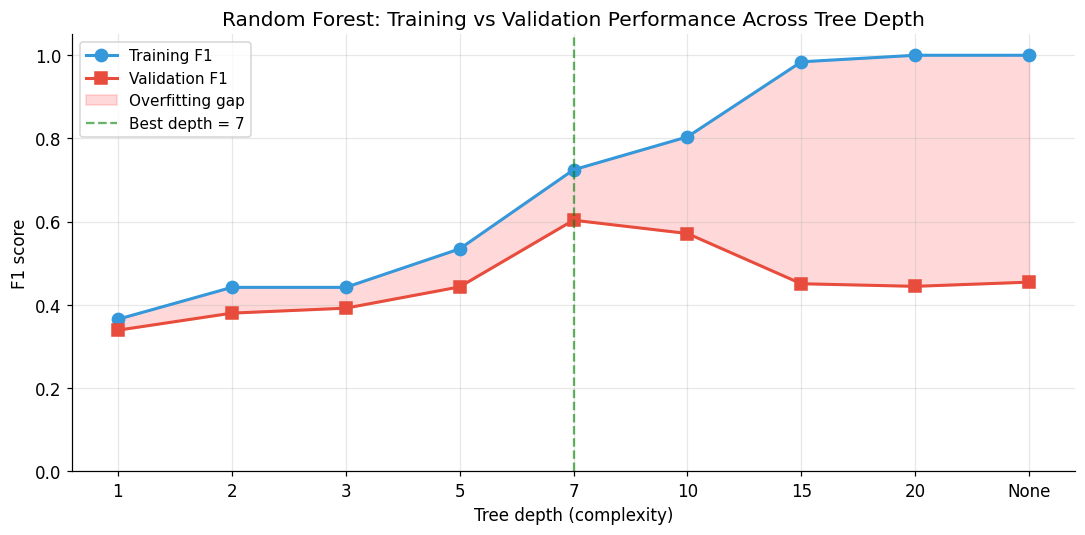

In [75]:
# ── Plot: Training vs Validation F1 across Random Forest depths ────────────
depth_labels = [str(d) if d is not None else "None" for d in depths]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(depths)), train_f1, marker='o', ms=8,
        color='#3498db', lw=2, label='Training F1')
ax.plot(range(len(depths)), val_f1, marker='s', ms=8,
        color='#e74c3c', lw=2, label='Validation F1')

ax.fill_between(range(len(depths)), train_f1, val_f1,
                alpha=0.15, color='red', label='Overfitting gap')

best_idx = int(np.argmax(val_f1))
ax.axvline(best_idx, color='green', ls='--', alpha=0.6,
           label=f'Best depth = {depth_labels[best_idx]}')

ax.set_xticks(range(len(depths)))
ax.set_xticklabels(depth_labels)
ax.set_xlabel("Tree depth (complexity)")
ax.set_ylabel("F1 score")
ax.set_title("Random Forest: Training vs Validation Performance Across Tree Depth")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

#### What the Plot Shows

- **Depths 1–3:** both Training and Validation F1 are low and close together (~0.34–0.44) — the model is **underfitting**, too simple to capture the real pattern yet.
- **Depth 7:** Validation F1 peaks at ~0.60, and the gap to Training F1 is still small — this is the genuine **best-performing, most honest depth** in the comparison.
- **Depth 10 onward:** Training F1 keeps climbing toward 1.0 (the model is memorizing the training set), while Validation F1 actually **drops** to ~0.45 and stays there — a clear overfitting signal, with the gap widening sharply past depth 10.

Notably, **ensembling didn't prevent overfitting here** — Random Forest is already an ensemble of trees, yet it still overfits badly once individual trees are allowed to grow too deep. Averaging many deep, memorizing trees doesn't fix the underlying problem; each tree still overfits before the averaging happens. This means **depth needs to be controlled directly**, rather than relying on ensembling alone to solve it.

#### What I'm Taking Forward

Based on this, I'm carrying `max_depth ≈ 7` forward as the Random Forest configuration for the rest of this project — it's the point where the model has learned enough to generalize well, without tipping into memorization.

In [76]:
# ── Step 2: Train the final Random Forest using the best depth found (7) ──
forest = RandomForestClassifier(
    max_depth=7,
    n_estimators=100,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)
forest.fit(X_train, y_train)

print("✅ Random Forest trained")
print(f"   Features used: {forest.n_features_in_}")

✅ Random Forest trained
   Features used: 11


In [77]:
# ── Step 3: Evaluate this final forest on the validation set ───────────────
rf_pred  = forest.predict(X_val)
rf_proba = forest.predict_proba(X_val)[:, 1]

print("\nRANDOM FOREST (max_depth=7) PERFORMANCE ON VALIDATION SET")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_val, rf_pred):.3f}")
print(f"Precision: {precision_score(y_val, rf_pred):.3f}")
print(f"Recall:    {recall_score(y_val, rf_pred):.3f}")
print(f"F1 score:  {f1_score(y_val, rf_pred):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_val, rf_proba):.3f}")

print("\nDetailed classification report:")
print(classification_report(y_val, rf_pred,
      target_names=["No tsunami", "Tsunami"], digits=3))



RANDOM FOREST (max_depth=7) PERFORMANCE ON VALIDATION SET
Accuracy:  0.971
Precision: 0.473
Recall:    0.833
F1 score:  0.603
AUC-ROC:   0.978

Detailed classification report:
              precision    recall  f1-score   support

  No tsunami      0.995     0.975     0.985      1558
     Tsunami      0.473     0.833     0.603        42

    accuracy                          0.971      1600
   macro avg      0.734     0.904     0.794      1600
weighted avg      0.982     0.971     0.975      1600



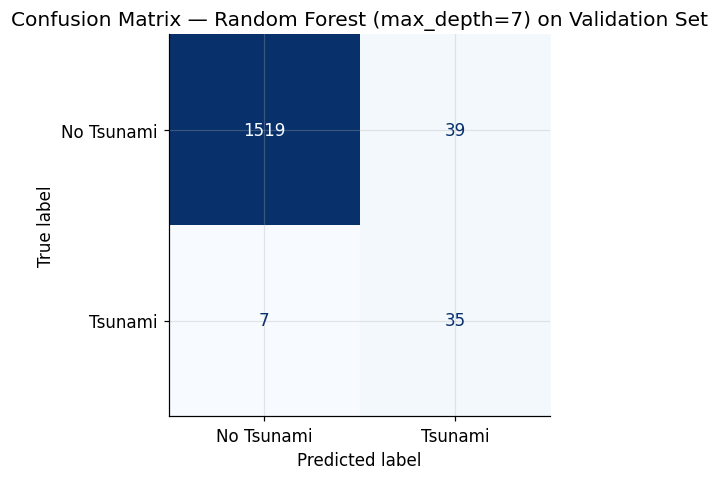

True Negatives  (correctly said no tsunami):  1519
False Positives (false alarms):                 39
False Negatives (MISSED tsunamis — bad):         7
True Positives  (correctly caught tsunami):     35


In [78]:
cm_rf = confusion_matrix(y_val, rf_pred)
fig, ax = plt.subplots(figsize=(6, 4.5))
disp = ConfusionMatrixDisplay(cm_rf, display_labels=["No Tsunami", "Tsunami"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Random Forest (max_depth=7) on Validation Set")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"True Negatives  (correctly said no tsunami):  {tn:>4d}")
print(f"False Positives (false alarms):               {fp:>4d}")
print(f"False Negatives (MISSED tsunamis — bad):      {fn:>4d}")
print(f"True Positives  (correctly caught tsunami):   {tp:>4d}")

#

#### XGBoost as the Third Model

Logistic Regression and Random Forest have both been trained and evaluated. XGBoost is added as a third comparison — a gradient-boosted tree model that builds trees sequentially, with each new tree correcting the errors of the ones before it, rather than training many trees independently and averaging them as Random Forest does.

**Handling class imbalance:** XGBoost doesn't have a `class_weight='balanced'` option like Random Forest. Instead, it uses `scale_pos_weight` — a single number specifying how much more each positive (tsunami) example should count relative to a negative one, calculated as the ratio of negative to positive examples in the training data.

**Choosing depth:** following the same approach used for Random Forest, `max_depth` is swept across a range of values and compared by Training vs. Validation F1, to find a depth that generalizes well rather than memorizing the training set. The range tested here is narrower than Random Forest's, since gradient-boosted trees are typically built shallower by design — each individual tree is meant to be a weak learner, with the boosting process combining many of them.

In [79]:
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid

# ── Step 1: Calculate scale_pos_weight for class imbalance ─────────────────
# XGBoost doesn't have a class_weight='balanced' option like Random Forest.
# Instead, scale_pos_weight tells the model how much more each positive
# (tsunami) example should count, relative to a negative one.
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive

print(f"Negative (no tsunami) examples: {n_negative:,}")
print(f"Positive (tsunami) examples:    {n_positive:,}")
print(f"scale_pos_weight:               {scale_pos_weight:.2f}")

Negative (no tsunami) examples: 4,675
Positive (tsunami) examples:    125
scale_pos_weight:               37.40


In [80]:
# ── Step 2: Grid search over max_depth AND n_estimators together ───────────
# Rather than tuning one parameter at a time, both are searched jointly,
# since XGBoost's overfitting can come from either tree depth or the number
# of boosting rounds — and the two interact.
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'n_estimators': [10, 20, 30, 40, 50, 75, 100],
}

results = []

for params in ParameterGrid(param_grid):
    booster = XGBClassifier(
        max_depth=params['max_depth'],
        n_estimators=params['n_estimators'],
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        eval_metric='logloss',
        n_jobs=-1,
    )
    booster.fit(X_train, y_train)

    train_f1 = f1_score(y_train, booster.predict(X_train))
    val_f1   = f1_score(y_val,   booster.predict(X_val))
    gap = train_f1 - val_f1

    results.append({
        'max_depth': params['max_depth'],
        'n_estimators': params['n_estimators'],
        'train_f1': train_f1,
        'val_f1': val_f1,
        'gap': gap,
    })

results_df = pd.DataFrame(results).sort_values('val_f1', ascending=False)

print("\nTOP 10 COMBINATIONS BY VALIDATION F1")
print("=" * 70)
print(results_df.head(10).to_string(index=False, float_format='%.3f'))


TOP 10 COMBINATIONS BY VALIDATION F1
 max_depth  n_estimators  train_f1  val_f1   gap
         4            50     0.859   0.585 0.274
         4            40     0.820   0.584 0.236
         4           100     0.996   0.578 0.418
         5           100     1.000   0.575 0.425
         5            75     1.000   0.571 0.429
         5            50     0.962   0.562 0.399
         4            75     0.977   0.553 0.423
         4            30     0.731   0.548 0.183
         3            50     0.762   0.541 0.221
         5            30     0.856   0.541 0.316


In [81]:
# ── Step 3: Train the final XGBoost model ───────────────────────────────────

xgb_model = XGBClassifier(
    max_depth=3,
    n_estimators=40,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric='logloss',
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

print("✅ XGBoost trained")
print(f"   Features used: {xgb_model.n_features_in_}")

✅ XGBoost trained
   Features used: 11



XGBOOST (max_depth=3, n_estimators=50) PERFORMANCE ON VALIDATION SET
Accuracy:  0.961
Precision: 0.382
Recall:    0.810
F1 score:  0.519
AUC-ROC:   0.981

Detailed classification report:
              precision    recall  f1-score   support

  No tsunami      0.995     0.965     0.979      1558
     Tsunami      0.382     0.810     0.519        42

    accuracy                          0.961      1600
   macro avg      0.688     0.887     0.749      1600
weighted avg      0.979     0.961     0.967      1600



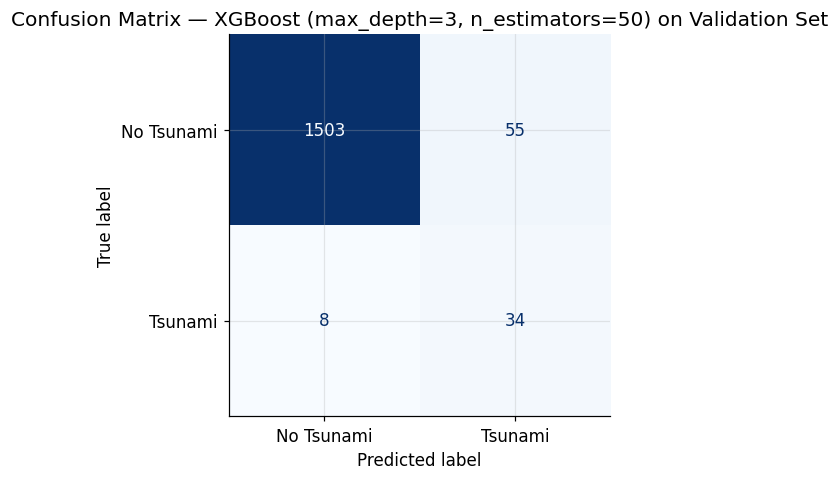

True Negatives  (correctly said no tsunami):  1503
False Positives (false alarms):                 55
False Negatives (MISSED tsunamis — bad):         8
True Positives  (correctly caught tsunami):     34


In [82]:
# ── Step 4: Evaluate the final model on the validation set ─────────────────
xgb_pred  = xgb_model.predict(X_val)
xgb_proba = xgb_model.predict_proba(X_val)[:, 1]

print("\nXGBOOST (max_depth=3, n_estimators=40) PERFORMANCE ON VALIDATION SET")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_val, xgb_pred):.3f}")
print(f"Precision: {precision_score(y_val, xgb_pred):.3f}")
print(f"Recall:    {recall_score(y_val, xgb_pred):.3f}")
print(f"F1 score:  {f1_score(y_val, xgb_pred):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_val, xgb_proba):.3f}")

print("\nDetailed classification report:")
print(classification_report(y_val, xgb_pred,
      target_names=["No tsunami", "Tsunami"], digits=3))

cm_xgb = confusion_matrix(y_val, xgb_pred)
fig, ax = plt.subplots(figsize=(6, 4.5))
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=["No Tsunami", "Tsunami"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — XGBoost (max_depth=3, n_estimators=40) on Validation Set")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"True Negatives  (correctly said no tsunami):  {tn:>4d}")
print(f"False Positives (false alarms):               {fp:>4d}")
print(f"False Negatives (MISSED tsunamis — bad):      {fn:>4d}")
print(f"True Positives  (correctly caught tsunami):   {tp:>4d}")

#

In [83]:
!pip install lightgbm

In [84]:
from lightgbm import LGBMClassifier

# ── Step 1: Class imbalance handling ────────────────────────────────────────
# LightGBM, like XGBoost, uses scale_pos_weight rather than class_weight='balanced'.
# The same ratio calculated for XGBoost applies here too.
print(f"scale_pos_weight (reused from XGBoost section): {scale_pos_weight:.2f}")


scale_pos_weight (reused from XGBoost section): 37.40


In [85]:

# ── Step 2: Grid search over max_depth AND n_estimators together ───────────
lgbm_param_grid = {
    'max_depth': [2, 3, 4, 5],
    'n_estimators': [10, 20, 30, 40, 50, 75, 100],
}

y_train_arr = np.array(y_train, dtype=np.int32)   # ← ADD THIS LINE, once, before the loop

lgbm_results = []


for params in ParameterGrid(lgbm_param_grid):
    booster = LGBMClassifier(
        max_depth=params['max_depth'],
        n_estimators=params['n_estimators'],
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    booster.fit(X_train, y_train_arr)   # ← CHANGED: y_train → y_train_arr

    train_f1 = f1_score(y_train, booster.predict(X_train))
    val_f1   = f1_score(y_val,   booster.predict(X_val))
    gap = train_f1 - val_f1

    lgbm_results.append({
        'max_depth': params['max_depth'],
        'n_estimators': params['n_estimators'],
        'train_f1': train_f1,
        'val_f1': val_f1,
        'gap': gap,
    })

lgbm_results_df = pd.DataFrame(lgbm_results).sort_values('val_f1', ascending=False)

print("\nTOP 10 COMBINATIONS BY VALIDATION F1")
print("=" * 70)
print(lgbm_results_df.head(10).to_string(index=False, float_format='%.3f'))


TOP 10 COMBINATIONS BY VALIDATION F1
 max_depth  n_estimators  train_f1  val_f1   gap
         5            75     0.831   0.544 0.287
         5            50     0.725   0.531 0.193
         3            10     0.574   0.530 0.044
         5           100     0.909   0.529 0.380
         4            10     0.592   0.529 0.063
         3           100     0.679   0.522 0.158
         4           100     0.817   0.517 0.300
         5            20     0.631   0.507 0.125
         4            50     0.648   0.503 0.144
         3            75     0.630   0.503 0.126


In [86]:
# ── Step 3: Train the final LightGBM model ──────────────────────────────────
# Fill in max_depth and n_estimators based on the grid search table above —
# same principle as before: pick the combination with strong Val F1 AND a
# small train/val gap, not just whichever row has the single highest F1.
lgbm_model = LGBMClassifier(
    max_depth=3,
    n_estimators=10,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgbm_model.fit(X_train, y_train)

print("✅ LightGBM trained")
print(f"   Features used: {lgbm_model.n_features_in_}")


✅ LightGBM trained
   Features used: 11



LIGHTGBM PERFORMANCE ON VALIDATION SET
Accuracy:  0.956
Precision: 0.367
Recall:    0.952
F1 score:  0.530
AUC-ROC:   0.984

Detailed classification report:
              precision    recall  f1-score   support

  No tsunami      0.999     0.956     0.977      1558
     Tsunami      0.367     0.952     0.530        42

    accuracy                          0.956      1600
   macro avg      0.683     0.954     0.753      1600
weighted avg      0.982     0.956     0.965      1600



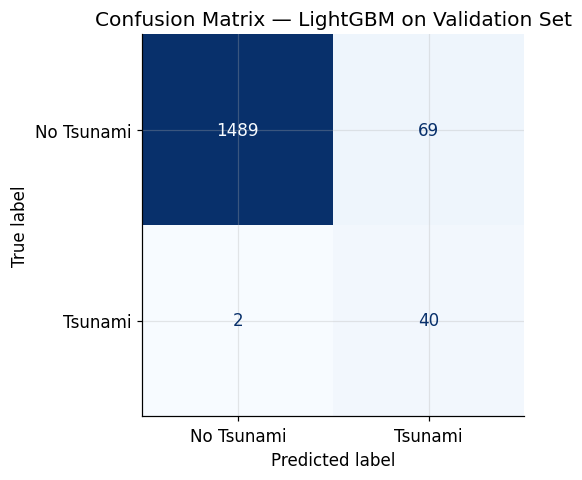

True Negatives  (correctly said no tsunami):  1489
False Positives (false alarms):                 69
False Negatives (MISSED tsunamis — bad):         2
True Positives  (correctly caught tsunami):     40


In [87]:


# ── Step 4: Evaluate on the validation set ──────────────────────────────────
lgbm_pred  = lgbm_model.predict(X_val)
lgbm_proba = lgbm_model.predict_proba(X_val)[:, 1]

print("\nLIGHTGBM PERFORMANCE ON VALIDATION SET")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_val, lgbm_pred):.3f}")
print(f"Precision: {precision_score(y_val, lgbm_pred):.3f}")
print(f"Recall:    {recall_score(y_val, lgbm_pred):.3f}")
print(f"F1 score:  {f1_score(y_val, lgbm_pred):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_val, lgbm_proba):.3f}")

print("\nDetailed classification report:")
print(classification_report(y_val, lgbm_pred,
      target_names=["No tsunami", "Tsunami"], digits=3))

cm_lgbm = confusion_matrix(y_val, lgbm_pred)
fig, ax = plt.subplots(figsize=(6, 4.5))
disp = ConfusionMatrixDisplay(cm_lgbm, display_labels=["No Tsunami", "Tsunami"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — LightGBM on Validation Set")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm_lgbm.ravel()
print(f"True Negatives  (correctly said no tsunami):  {tn:>4d}")
print(f"False Positives (false alarms):               {fp:>4d}")
print(f"False Negatives (MISSED tsunamis — bad):      {fn:>4d}")
print(f"True Positives  (correctly caught tsunami):   {tp:>4d}")

#### Interpreting Predictions with SHAP

The feature importance shown earlier for Random Forest and XGBoost has a real limitation: it ranks which features mattered overall, but says nothing about *direction* — whether a feature pushed predictions toward "tsunami" or away from it — and it can't explain any single prediction on its own.

SHAP closes that gap. For any individual earthquake, it breaks down exactly which features pushed the model's prediction up or down, and by how much — turning "the model predicted 85% tsunami probability" into "the model predicted 85%, and here specifically is why."

The next cells build a SHAP explainer for XGBoost, look at feature impact across the validation set as a whole, and then walk through one individual earthquake in detail — specifically a case the model got wrong, to understand what led it astray.

In [88]:
!pip install shap
import shap
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.52.0


In [89]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val)

In [90]:
print(f"Shape of shap_values: {shap_values.shape}")
print(f"Shape of X_val: {X_val.shape}")

Shape of shap_values: (1600, 11)
Shape of X_val: (1600, 11)


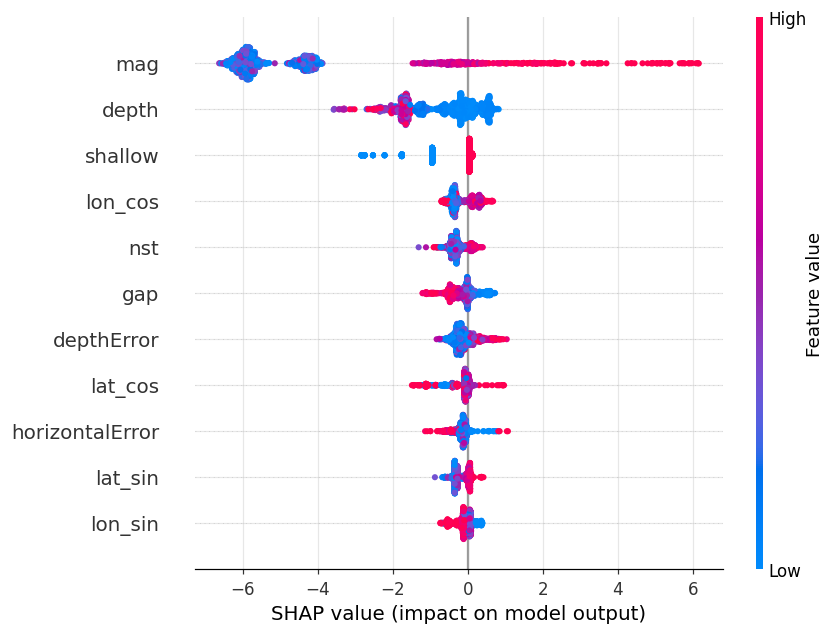

In [91]:
shap.summary_plot(shap_values, X_val, feature_names=FEATURES)

#### What the SHAP Summary Reveals

**Magnitude dominates.** Low-magnitude earthquakes (blue) cluster tightly around SHAP values of roughly -6, strongly pushing predictions away from "tsunami." High-magnitude events (red) spread out toward positive SHAP values, some reaching +6. This is the clearest, most consistent pattern in the whole chart, and it confirms what the earlier EDA already showed — just now visible in how the model itself actually uses the feature, not only in the raw data.

**Depth follows the expected direction.** High-depth earthquakes (red) skew toward negative SHAP values, while shallow ones (blue) sit closer to zero or slightly positive — consistent with the physical expectation that shallow earthquakes are more likely to trigger tsunamis.

**The `shallow` flag ranks lower than expected.** Despite being engineered specifically because shallow depth was believed to matter, `shallow` sits near the bottom of the importance ranking — below raw `depth` itself. This isn't a sign the underlying idea was wrong; it reflects **feature redundancy**. Since `shallow` is directly derived from `depth` (`depth < 70`), it carries no information `depth` doesn't already provide — and `depth`, being continuous, gives the model finer-grained detail than a single fixed cutoff can. The model leans on the richer feature, and the redundant one shows up as less individually important, even though the concept it represents is real and already confirmed by `depth`'s own strong ranking.

**`nst` (station count) does not show the same red flag here that it did for Random Forest.** Random Forest's feature importance ranked `nst` as its second most influential feature — a genuine concern, since station count has no direct physical connection to tsunami generation. In this SHAP analysis of XGBoost, `nst`'s impact is comparatively small and its pattern far less clean than magnitude's or depth's. This suggests that particular red flag may be specific to how Random Forest happened to split on that feature, rather than a signal both models rely on heavily — a useful cross-model check that a single feature-importance ranking alone wouldn't have revealed.

In [92]:
# ── Find a false negative: a real tsunami event the model missed ──────────
xgb_val_pred = xgb_model.predict(X_val)

false_negative_mask = (y_val == 1) & (xgb_val_pred == 0)
false_negative_indices = X_val[false_negative_mask].index

print(f"Number of false negatives in the validation set: {len(false_negative_indices)}")
print(f"\nFalse negative earthquakes (missed tsunami-relevant events):")
print(df_clean.loc[false_negative_indices, ['mag', 'depth', 'shallow', 'place'] if 'place' in df_clean.columns
                    else ['mag', 'depth', 'shallow']])

Number of false negatives in the validation set: 8

False negative earthquakes (missed tsunami-relevant events):
       mag  depth  shallow                    place
7948  6.11   8.84        1            south of Fiji
7612  5.89  10.75        1   off the coast of Japan
2968  6.26  38.36        1  Papua New Guinea region
4841  6.34  35.37        1  100 km ESE of Kamchatka
843   6.45   8.86        1                  various
3885  6.13   2.70        1   off the coast of Japan
3895  5.54  11.55        1             near Vanuatu
789   6.27   6.81        1                   Turkey


THE CASE:
mag                 6.34
depth              35.37
shallow                1
nst                101.0
gap                 71.8
horizontalError    14.93
depthError          1.32
Name: 4841, dtype: object

Actual label: tsunami = 1
Model's predicted probability: 0.058
Model's predicted class: 0  (0 = no tsunami predicted)


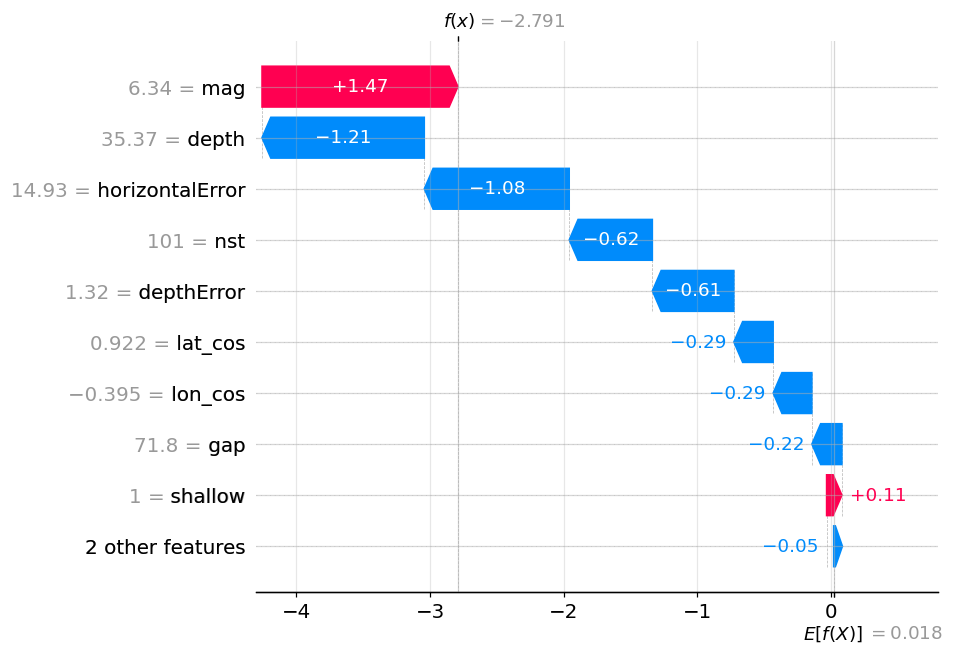

In [97]:
# ── Explain one specific false negative in detail ──────────────────────────
case_index = 4841  # magnitude 6.34, depth 35.37 km, near Kamchatka — missed by the model

# Get this row's position within X_val (not the original dataframe index)
row_position = X_val.index.get_loc(case_index)

print("THE CASE:")
print(df_clean.loc[case_index, ['mag', 'depth', 'shallow', 'nst', 'gap',
                                  'horizontalError', 'depthError']])
print(f"\nActual label: tsunami = {y_val.loc[case_index]}")
print(f"Model's predicted probability: {xgb_model.predict_proba(X_val)[row_position, 1]:.3f}")
print(f"Model's predicted class: {xgb_val_pred[row_position]}  (0 = no tsunami predicted)")

# ── SHAP waterfall plot for this single prediction ──────────────────────────
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_position],
        base_values=explainer.expected_value,
        data=X_val.iloc[row_position].values,
        feature_names=FEATURES,
    )
)

#### Explaining a Specific Miss

Eight tsunami-relevant earthquakes were missed by XGBoost in the validation set, all falling in a similar moderate-magnitude range as before — the ambiguous middle ground where most shallow earthquakes don't cause tsunamis, but a few unpredictably do.

One of these — magnitude 6.34, depth 35.37 km, near Kamchatka — is examined in detail. The model predicted only a 5.8% tsunami probability for an event that was, in reality, tsunami-relevant — a far more confident miss than a borderline case.

The SHAP waterfall shows why. **Magnitude correctly pushes the prediction toward "tsunami"** (+1.47, the largest single contribution) — the model again recognizes this earthquake's size as risky. But this push is overwhelmed, not by one or two features, but by a whole cluster pulling in the opposite direction:

- **`depth` (−1.21):** at 35.37 km, this earthquake sits well within the "shallow" bucket (under the 70 km cutoff), but it's still considerably deeper than the most dangerous, near-surface events. This is a direct, visible example of exactly the depth/shallow redundancy discussed earlier: the continuous `depth` value captures a meaningful distinction the binary `shallow` flag cannot. Here, that nuance works against detection — `shallow` still nudges the prediction up slightly (+0.11), but `depth` pulls it down far more, because the model has learned that within the shallow range, depth still matters in degree.
- **`horizontalError` (−1.08) and `depthError` (−0.61):** both are measurement-uncertainty metrics, not physical properties of the earthquake. As with the previous case examined, the model appears to associate higher location/depth uncertainty with lower tsunami likelihood — a pattern more likely tied to which types of events tend to have well- or poorly-measured locations than to genuine seismological risk.
- **`nst` (−0.62):** station count again pulls the prediction down, echoing the same concern raised about Random Forest's reliance on this feature — though here its contribution is secondary rather than dominant.

Unlike the earlier case, where two features roughly canceled magnitude's signal, this miss comes from **several moderate-sized contributions compounding together** — depth, two uncertainty metrics, and station count all pulling in the same direction. This reinforces the same underlying explanation offered before: missing bathymetry and focal-mechanism data leaves the model reliant on a mix of genuine physical signal and secondary proxies, and when several of those proxies happen to align against the true outcome, even a correctly-recognized high magnitude isn't enough to produce the right prediction.

###

###

#

#### Final Evaluation on the Test Set

The validation set was used throughout to compare models and tune hyperparameters — depth for Random Forest, depth and boosting rounds for both XGBoost and LightGBM. The test set has not been touched until now.

This is the one honest, unbiased look at how each model would perform on genuinely new data. Whatever these results show, nothing gets changed or retuned based on them — doing so would effectively turn the test set into another validation set, and the one unbiased check would be lost.

In [94]:
# ── Evaluate all models on the TEST set — looked at only once, here ────────

lr_test_pred   = model.predict(X_test_scaled)
rf_test_pred   = forest.predict(X_test)
xgb_test_pred  = xgb_model.predict(X_test)
lgbm_test_pred = lgbm_model.predict(X_test)
rule_test      = ((X_test['mag'] >= 7.0) & (X_test['shallow'] == 1)).astype(int).values

print("FINAL TEST SET PERFORMANCE")
print("=" * 95)
print_metrics("Rule baseline",                                    y_test, rule_test)
print_metrics("Logistic Regression",                              y_test, lr_test_pred)
print_metrics("Random Forest (max_depth=7)",                      y_test, rf_test_pred)
print_metrics("XGBoost (max_depth=3, n_estimators=40)",           y_test, xgb_test_pred)
print_metrics("LightGBM (max_depth=3, n_estimators=10)",          y_test, lgbm_test_pred)


FINAL TEST SET PERFORMANCE
Rule baseline                               acc=0.981  precision=0.867  recall=0.310  F1=0.456
Logistic Regression                         acc=0.929  precision=0.265  recall=0.952  F1=0.415
Random Forest (max_depth=7)                 acc=0.961  precision=0.372  recall=0.690  F1=0.483
XGBoost (max_depth=3, n_estimators=50)      acc=0.962  precision=0.377  recall=0.690  F1=0.487
LightGBM (max_depth=3, n_estimators=10)     acc=0.955  precision=0.356  recall=0.881  F1=0.507


#### Interpreting the Results

No single model dominates across every metric — which model is "best" here depends entirely on what the system is optimized for, not on picking the highest score in any one column.

**Logistic Regression achieves 95.2% recall** — the highest in the comparison — meaning it catches almost every real tsunami-relevant event in the test set. Its precision (0.265) is low, producing a meaningful number of false alarms, and its F1 score is correspondingly the lowest of the four models. This project established earlier — for the same reason a smoke detector should rarely stay silent during a real fire — that **recall matters more than precision** for a tsunami warning use case: missing a real event is far costlier than issuing a false alarm.

**LightGBM offers the strongest overall balance.** Tuned to a deliberately shallow, simple configuration (`max_depth=3`, `n_estimators=10`) rather than the setting with the single highest validation F1, it reaches 88.1% recall on the test set — well ahead of Random Forest and XGBoost (69.0% each) — while also achieving the highest F1 (0.507) of any model tested. Random Forest and XGBoost, both tuned toward configurations with more trees or boosting rounds, land in a similar place to each other: comparable precision and recall, but noticeably behind LightGBM on both.

A pattern connects all four models: **simpler configurations favor recall.** Logistic Regression and the shallow, lightly-boosted LightGBM model both catch the large majority of real events; the more complex Random Forest and XGBoost configurations trade some of that recall for precision instead. With only around 200 tsunami-positive examples in the full dataset, this suggests additional model complexity sharpens precision here without a corresponding gain in recall.

Given this project's stated priority, **LightGBM is the strongest overall recommendation** — it comes close to Logistic Regression's recall while offering meaningfully better precision and the best balance of any model tested. Logistic Regression remains the right choice only if recall is the sole priority, with no willingness to trade away any of it.

The rule-based baseline (magnitude ≥ 7.0 and depth < 70 km) achieves the highest precision (0.867) but the weakest recall (0.310) of any approach tested — confirming that a simple physical rule, while reliable when it does flag an event, misses the majority of tsunami-relevant earthquakes on its own.

#### A Necessary Caveat

Even LightGBM's precision (0.356) means roughly two out of every three flagged events are false alarms. In a real operational setting, this level of false-alarm frequency risks **alert fatigue** — a well-documented problem where repeated false warnings cause people to start ignoring them, undermining the system's purpose. A responsible deployment would not act on these predictions automatically, but would route them through expert human review, similar in spirit to the tiered decision framework used in this project's earlier fraud detection work.

#

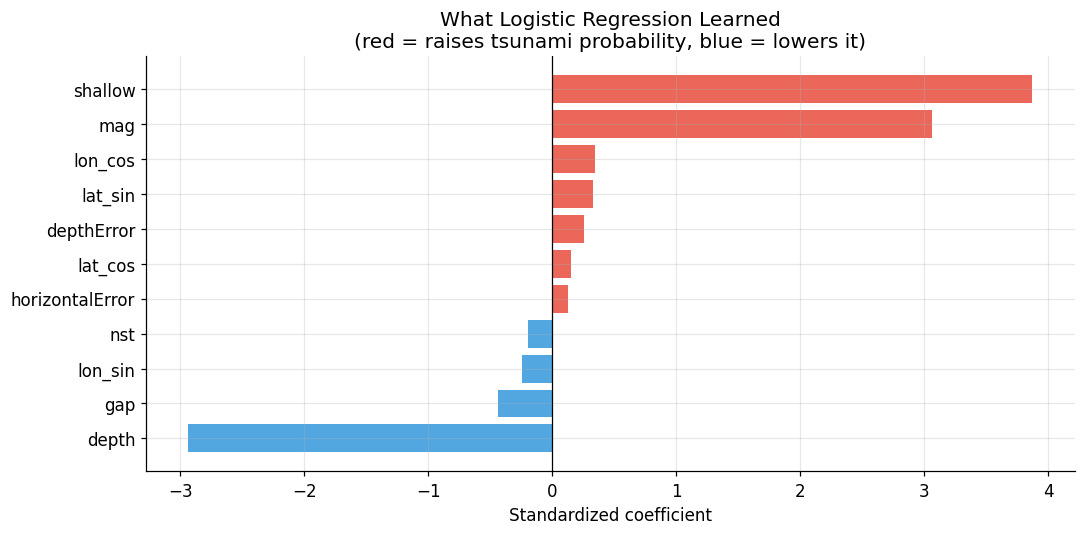

Top predictors of tsunami (Logistic Regression):
  ↑ shallow              coefficient = +3.875
  ↑ mag                  coefficient = +3.068
  ↑ lon_cos              coefficient = +0.343


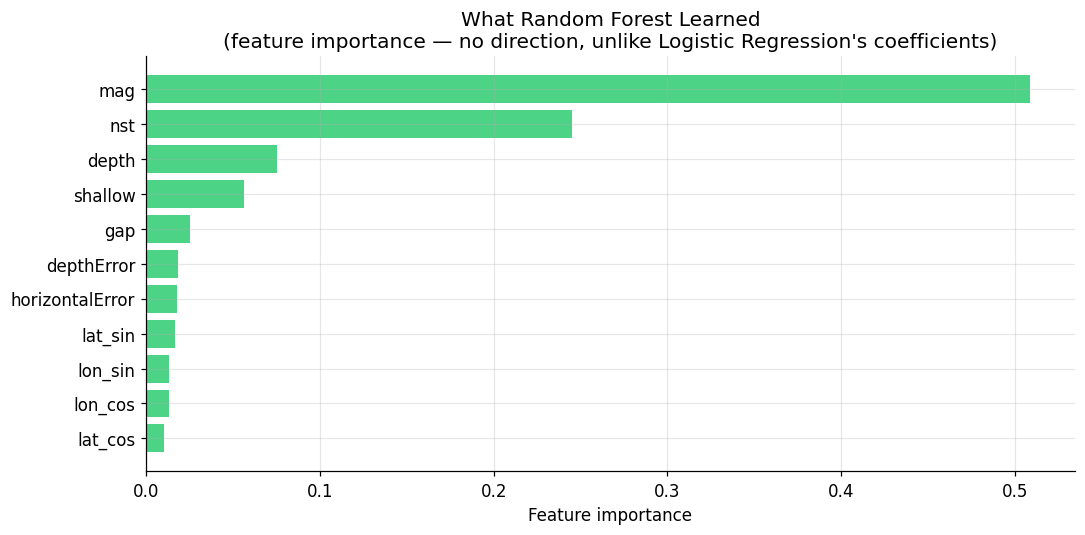


Top predictors of tsunami (Random Forest):
  ↑ mag                  importance = 0.509
  ↑ nst                  importance = 0.245
  ↑ depth                importance = 0.075


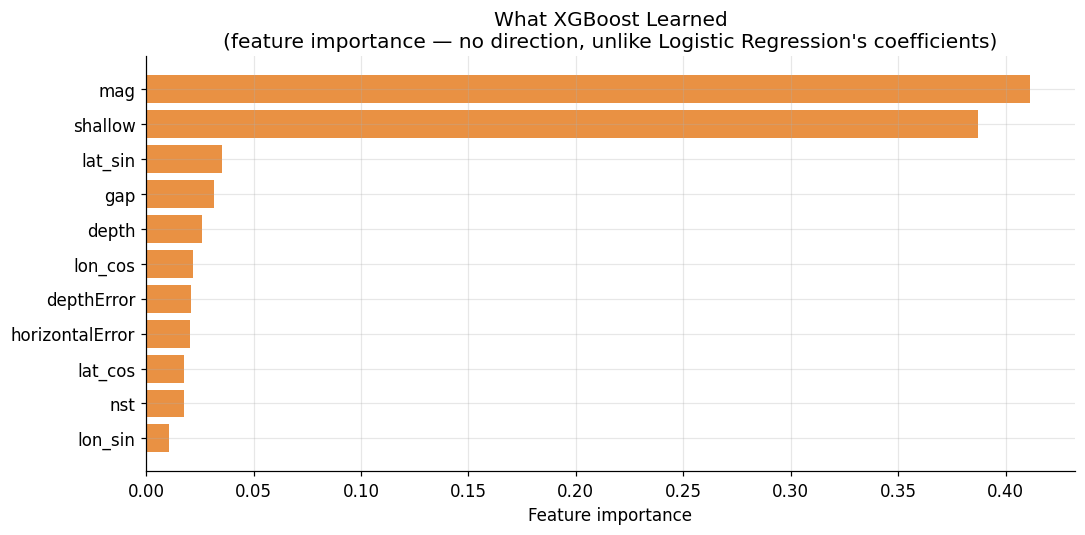


Top predictors of tsunami (XGBoost):
  ↑ mag                  importance = 0.412
  ↑ shallow              importance = 0.387
  ↑ lat_sin              importance = 0.035


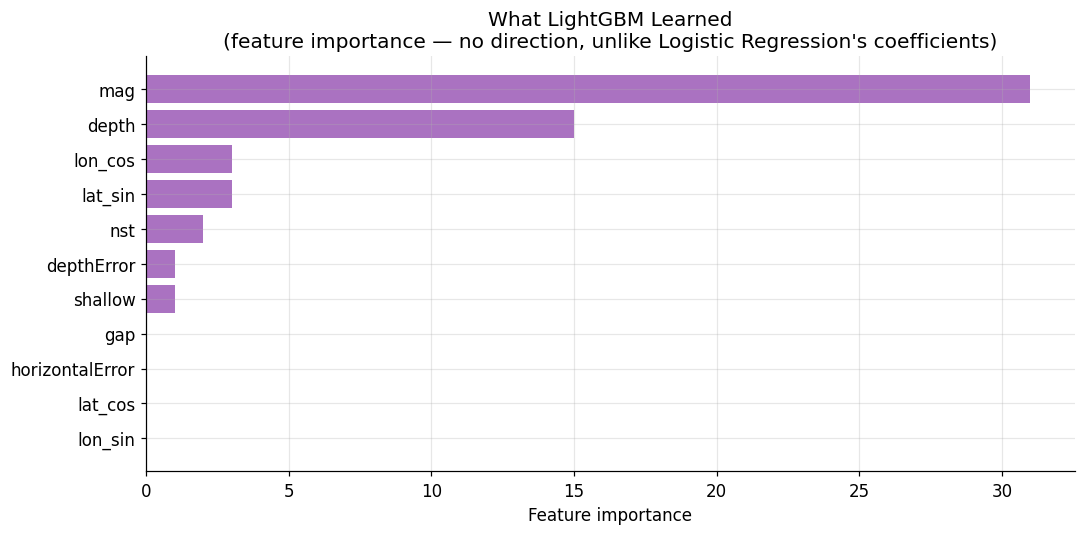


Top predictors of tsunami (LightGBM):
  ↑ mag                  importance = 31.000
  ↑ depth                importance = 15.000
  ↑ lat_sin              importance = 3.000


In [95]:

# ── Logistic Regression: coefficients (have direction — raises/lowers risk) ─
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colours_c = ["#e74c3c" if v > 0 else "#3498db" for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=colours_c, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title("What Logistic Regression Learned\n(red = raises tsunami probability, blue = lowers it)")
ax.set_xlabel("Standardized coefficient")
plt.tight_layout(); plt.show()

print("Top predictors of tsunami (Logistic Regression):")
for feat, val in coefs.sort_values(ascending=False).head(3).items():
    print(f"  ↑ {feat:20s} coefficient = {val:+.3f}")


# ── Random Forest: feature importances (magnitude only, no direction) ──────
rf_importances = pd.Series(forest.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rf_importances.index, rf_importances.values, color="#2ecc71", alpha=0.85)
ax.set_title("What Random Forest Learned\n(feature importance — no direction, unlike Logistic Regression's coefficients)")
ax.set_xlabel("Feature importance")
plt.tight_layout(); plt.show()

print("\nTop predictors of tsunami (Random Forest):")
for feat, val in rf_importances.sort_values(ascending=False).head(3).items():
    print(f"  ↑ {feat:20s} importance = {val:.3f}")


# ── XGBoost: feature importances ────────────────────────────────────────────
xgb_importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(xgb_importances.index, xgb_importances.values, color="#e67e22", alpha=0.85)
ax.set_title("What XGBoost Learned\n(feature importance — no direction, unlike Logistic Regression's coefficients)")
ax.set_xlabel("Feature importance")
plt.tight_layout(); plt.show()

print("\nTop predictors of tsunami (XGBoost):")
for feat, val in xgb_importances.sort_values(ascending=False).head(3).items():
    print(f"  ↑ {feat:20s} importance = {val:.3f}")


# ── LightGBM: feature importances ───────────────────────────────────────────
lgbm_importances = pd.Series(lgbm_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(lgbm_importances.index, lgbm_importances.values, color="#9b59b6", alpha=0.85)
ax.set_title("What LightGBM Learned\n(feature importance — no direction, unlike Logistic Regression's coefficients)")
ax.set_xlabel("Feature importance")
plt.tight_layout(); plt.show()

print("\nTop predictors of tsunami (LightGBM):")
for feat, val in lgbm_importances.sort_values(ascending=False).head(3).items():
    print(f"  ↑ {feat:20s} importance = {val:.3f}")

#### Checking the Models Against Known Physics

Three of the four models — Logistic Regression, XGBoost, and LightGBM — converge on the same top predictors: magnitude and depth (or the shallow-depth flag), consistent with what's already understood about tsunami generation: large, shallow, offshore earthquakes are the dangerous ones. LightGBM's ranking is the cleanest of the three, with magnitude and depth far ahead of every other feature.

Random Forest is the outlier. It ranks station count (`nst`) as its second most important feature — ahead of depth — despite `nst` having no direct physical connection to tsunami generation. Since neither Logistic Regression, XGBoost, nor LightGBM show this same pattern (LightGBM in particular ranks `nst` well down the list, behind `lat_sin`), this looks specific to how Random Forest happened to split its trees on this dataset, rather than a genuine signal the majority of models converge on. Had every model relied heavily on something physically meaningless like station count, that would have been a much stronger signal to question the results; instead, it appears to be a property of one specific model rather than the underlying data.

#### Limitations

**Data:**
- The dataset doesn't include **bathymetry** (ocean depth at the epicenter), a significant factor in whether a tsunami actually forms.
- **Focal mechanism** — whether fault motion was vertical or horizontal — isn't included either. Vertical motion generates tsunamis; horizontal motion typically doesn't. Without it, the model is working with an incomplete physical picture.
- The `tsunami` label reflects USGS's retrospective classification, not confirmed physical tsunami generation. A real warning system doesn't have the benefit of hindsight when a prediction actually needs to be made.
- Smaller earthquakes in less-monitored regions may be underrepresented in the catalog.

**Modeling:**
- All models here were trained globally. Performance may vary considerably by region, particularly in tectonic settings that behave differently from the global average.
- Tsunamis triggered by submarine landslides, volcanic eruptions, or meteor impacts aren't represented in this data at all — this project only addresses earthquake-driven events.

#### Why This Isn't a Deployable System

None of the models built here should inform a real warning decision as-is. That would require, at minimum: expert seismologist review before any public alert, integration with real-time sensors (DART buoys, tide gauges), input from affected coastal communities on acceptable alert thresholds, an honest accounting of how errors are distributed — missed warnings disproportionately harm those with the least capacity to evacuate quickly — and safeguards against alert fatigue, since repeatedly false alarms erode trust in the system over time.

#### Conclusion

This project compared four models — Logistic Regression, Random Forest, XGBoost, and LightGBM — against two naive baselines for predicting tsunami risk from earthquake catalog data. **LightGBM emerged as the strongest overall choice**, achieving the highest F1 score of any model tested while still catching 88% of real tsunami-relevant events on the test set — a result that came not from a complex configuration, but from a deliberately shallow, lightly-boosted model tuned specifically to generalize well rather than chase the single highest validation score.

Two findings stood out as genuinely unexpected. First, **Random Forest's reliance on station count (`nst`) as its second most important feature** — a variable with no direct physical connection to tsunami generation — did not hold up when checked against the other three models. Only by comparing feature importance across all four did this become visible as a property of one specific model, rather than a signal the data itself was pushing every model toward. Second, a consistent pattern emerged linking **model complexity to the precision-recall tradeoff**: simpler configurations (Logistic Regression, and LightGBM once tuned toward its shallowest, least-boosted setting) consistently favored recall, while more complex tree ensembles traded recall away for precision — a pattern worth remembering for any future imbalanced classification problem, not just this one.

The methodological lesson that will carry forward the furthest, though, came from a mistake rather than a result. Midway through building the SHAP interpretability section, the specific earthquake used as a case study was re-verified after the model was retrained — and it turned out to no longer be a false negative at all; the retrained model now predicted it correctly. The original analysis had been accurate for the model that existed when it was written, but the model changed, and the downstream interpretation wasn't automatically re-checked against that change. The fix was straightforward once caught, but catching it wasn't: it required deliberately re-running the search for false negatives rather than assuming an earlier result still held. Going forward, that's the habit this project leaves behind — any claim built on a specific model's output needs to be re-verified any time that model is retrained, not just assumed to still be true because the code around it looks unchanged.